In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import random
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [27]:
def string_distance(str1: str, str2: str):
        len_str1 = len(str1) + 1
        len_str2 = len(str2) + 1

        distance_matrix = [[0] * len_str2 for _ in range(len_str1)]

        for i in range(len_str1):
            distance_matrix[i][0] = i
        for j in range(len_str2):
            distance_matrix[0][j] = j

        for i in range(1, len_str1):
            for j in range(1, len_str2):
                if str1[i - 1] == str2[j - 1]:
                    cost = 0
                else:
                    cost = 1

                distance_matrix[i][j] = min(distance_matrix[i - 1][j] + 1,
                                            distance_matrix[i][j - 1] + 1,
                                            distance_matrix[i - 1][j - 1] + cost)

        return distance_matrix[-1][-1]

In [28]:
def get_image_paths(dataset_path: str) -> list:
    image_paths = []
    for document in os.listdir(dataset_path):
        if "." in document:
            # Is a file
            continue
        for image in os.listdir(os.path.join(dataset_path, document)):
            basename = os.path.basename(image)
            # words.append(basename.split("-")[1].split(".")[0].lower())
            image_paths.append(os.path.join(document, image))

    return image_paths

In [29]:
image_paths = get_image_paths("../datasets/word_dataset")
print(len(image_paths))
print([random.choice(image_paths) for _ in range(5)])

4800
['AUR_953_XI_29-101 (text)\\1-nomine.png', 'AUR_970_III_7-101 (text)\\39-rebus.png', 'AUR_909_II_19-101 (text)\\61-seu.png', 'AUR_1055_III_06-101 (text)\\252-Data.png', 'AUR_945_VI_4-101 (text)\\141-ut.png']


In [30]:
train_images, test_images = train_test_split(image_paths, test_size=0.1, random_state=42)
train_images, val_images = train_test_split(train_images, test_size=0.2, random_state=42)

print(f"{len(train_images)=}")
print(f"{len(val_images)=}")
print(f"{len(test_images)=}")

len(train_images)=3456
len(val_images)=864
len(test_images)=480


In [31]:
### Four minutes to run this cell
def get_all_pairs(images: list) -> pd.DataFrame:
    pairs = []
    for i in range(len(images)):
        first_word = os.path.basename(images[i]).split("-")[1].split(".")[0].lower()
        for j in range(i + 1, len(images)):
            second_word = os.path.basename(images[j]).split("-")[1].split(".")[0].lower()
            pair_data = {
                "first_image": images[i],
                "second_image": images[j],
                "distance": string_distance(first_word, second_word)
            }
            pairs.append(pair_data)

    return pd.DataFrame(pairs)

In [32]:
# 2.5 minutes to run
train_pairs_df = get_all_pairs(train_images)
train_pairs_df.head()

,first_image,second_image,distance
0,AUR_888_II_18-101 (text)\156-suae.png,AUR_816_II_5-101 (text)\277-ipsam.png,4
1,AUR_888_II_18-101 (text)\156-suae.png,AUR_1055_III_06-101 (text)\57-nostrae.png,4
2,AUR_888_II_18-101 (text)\156-suae.png,HHSTA_Salzburg_1070_03_21-2 (text)\94-animarum...,7
3,AUR_888_II_18-101 (text)\156-suae.png,AUR_888_II_18-101 (text)\246-actum.png,5
4,AUR_888_II_18-101 (text)\156-suae.png,HHSTA_Salzburg_1070_03_21-2 (text)\117-tui.png,3


In [33]:
val_pairs_df = get_all_pairs(val_images)
val_pairs_df.head()

,first_image,second_image,distance
0,AUR_859_X_1-101 (text)\46-praesentium.png,AUR_888_II_18-101 (text)\80-mancipiis.png,9
1,AUR_859_X_1-101 (text)\46-praesentium.png,AUR_1020_IV_23-101 (text)\202-Guntherius.png,8
2,AUR_859_X_1-101 (text)\46-praesentium.png,AUR_888_III_19-101 (text)\36-in.png,10
3,AUR_859_X_1-101 (text)\46-praesentium.png,AUR_970_III_7-101 (text)\101-ecclesiae.png,9
4,AUR_859_X_1-101 (text)\46-praesentium.png,AUR_816_II_5-101 (text)\135-circa.png,11


In [34]:
test_pairs_df = get_all_pairs(test_images)
test_pairs_df.head()

,first_image,second_image,distance
0,AUR_1020_IV_23-101 (text)\86-fluminis.png,AUR_891_III_9-101 (text)\63-Christicolarum.png,13
1,AUR_1020_IV_23-101 (text)\86-fluminis.png,AUR_891_89301\8-dicto.png,7
2,AUR_1020_IV_23-101 (text)\86-fluminis.png,AUR_889_X_5(15)-101 (text)\69-in.png,6
3,AUR_1020_IV_23-101 (text)\86-fluminis.png,AUR_1006_XII_7-101 (text)\105-et.png,8
4,AUR_1020_IV_23-101 (text)\86-fluminis.png,AUR_1020_IV_23-101 (text)\69-Hartvvico.png,8


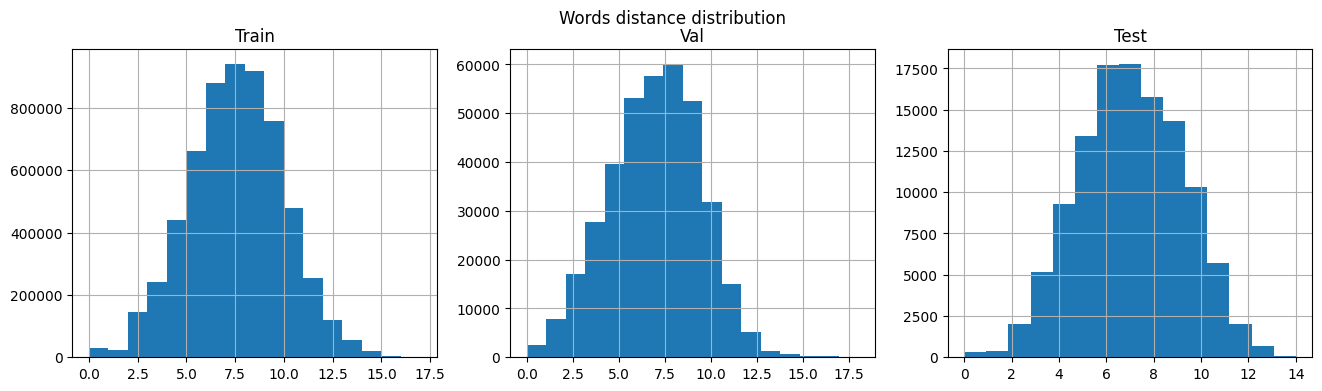

In [35]:
plt.figure(figsize=(16, 4))
plt.suptitle("Words distance distribution")
plt.subplot(131)
plt.hist(train_pairs_df["distance"], bins=17)
plt.title("Train")
plt.grid()

plt.subplot(132)
plt.hist(val_pairs_df["distance"], bins=17)
plt.title("Val")
plt.grid()

plt.subplot(133)
plt.hist(test_pairs_df["distance"], bins=15)
plt.title("Test")
plt.grid()

plt.show()

In [36]:
THRESHOLD = 1
SEPARATOR = ":"
def get_anchor_positives(paired_df: pd.DataFrame) -> pd.DataFrame:
    close_pairs = paired_df[paired_df["distance"] <= THRESHOLD]

    anchor_positives_dict: dict[str, list] = {}
    for _, row in close_pairs.iterrows():
        first_image = row["first_image"]
        second_image = row["second_image"]

        if first_image not in anchor_positives_dict:
            anchor_positives_dict[first_image] = [second_image]
        else:
            anchor_positives_dict[first_image].append(second_image)

        if second_image not in anchor_positives_dict:
            anchor_positives_dict[second_image] = [first_image]
        else:
            anchor_positives_dict[second_image].append(first_image)

    anchor_positives_data = []
    for key, value in anchor_positives_dict.items():
        anchor_positives_data.append({
            "anchor": key, "positive": SEPARATOR.join(value)
        })
    
    return pd.DataFrame(anchor_positives_data)


In [37]:
train_anchor_positives_df = get_anchor_positives(train_pairs_df)
train_anchor_positives_df

,anchor,positive
0,AUR_888_II_18-101 (text)\156-suae.png,AUR_891_III_9-101 (text)\95-suae.png:AUR_945_V...
1,AUR_891_III_9-101 (text)\95-suae.png,AUR_888_II_18-101 (text)\156-suae.png:AUR_945_...
2,AUR_945_VI_4-101 (text)\90-quae.png,AUR_888_II_18-101 (text)\156-suae.png:AUR_891_...
3,AUR_888_V_16-VI_1301 (text)\49-suam.png,AUR_888_II_18-101 (text)\156-suae.png:AUR_891_...
4,AUR_889_X_5(15)-101 (text)\151-quae.png,AUR_888_II_18-101 (text)\156-suae.png:AUR_891_...
...,...,...
2769,HHSTA_Salzburg_1070_03_21-2 (text)\265-constit...,HHSTA_Salzburg_1070_03_21-2 (text)\49-constitu...
2770,AUR_953_XI_29-101 (text)\73-aliis.png,AUR_945_VI_4-101 (text)\99-aliis.png
2771,AUR_945_VI_4-101 (text)\99-aliis.png,AUR_953_XI_29-101 (text)\73-aliis.png
2772,AUR_909_II_19-101 (text)\50-necnon.png,AUR_1006_XII_7-101 (text)\118-necnon.png


In [38]:
val_anchor_positives_df = get_anchor_positives(val_pairs_df)
val_anchor_positives_df.head()

,anchor,positive
0,AUR_888_II_18-101 (text)\80-mancipiis.png,AUR_881_X_14-101 (text)\68-mancipiis.png:AUR_9...
1,AUR_881_X_14-101 (text)\68-mancipiis.png,AUR_888_II_18-101 (text)\80-mancipiis.png:AUR_...
2,AUR_970_III_7-101 (text)\279-mancipiis.png,AUR_888_II_18-101 (text)\80-mancipiis.png:AUR_...
3,AUR_945_VI_4-101 (text)\92-mancipiis.png,AUR_888_II_18-101 (text)\80-mancipiis.png:AUR_...
4,AUR_889_X_5(15)-101 (text)\84-mancipiis.png,AUR_888_II_18-101 (text)\80-mancipiis.png:AUR_...


In [39]:
test_anchor_positives_df = get_anchor_positives(test_pairs_df)
test_anchor_positives_df.head()

,anchor,positive
0,AUR_891_89301\8-dicto.png,AUR_888_V_16-VI_1301 (text)\39-dicto.png
1,AUR_888_V_16-VI_1301 (text)\39-dicto.png,AUR_891_89301\8-dicto.png
2,AUR_889_X_5(15)-101 (text)\69-in.png,AUR_891_III_9-101 (text)\108-id.png:AUR_889_X_...
3,AUR_891_III_9-101 (text)\108-id.png,AUR_889_X_5(15)-101 (text)\69-in.png:AUR_889_X...
4,AUR_889_X_5(15)-101 (text)\236-II.png,AUR_889_X_5(15)-101 (text)\69-in.png:AUR_891_I...


In [40]:
train_anchor_positives_df.to_csv("../datasets/word_dataset/train.csv", index=False)
val_anchor_positives_df.to_csv("../datasets/word_dataset/val.csv", index=False)
test_anchor_positives_df.to_csv("../datasets/word_dataset/test.csv", index=False)

#### Balancing

In [41]:
def get_word_from_image_name(image_name: str) -> str:
    return os.path.basename(image_name).split("-")[1].split(".")[0].lower()

In [42]:
def balance_dataframe(df: pd.DataFrame, n_samples_per_word: int) -> pd.DataFrame:
    df["anchor_word"] = df["anchor"].apply(get_word_from_image_name)
    words = set(df["anchor_word"].tolist())
    balanced_data = []
    for word in words:
        word_df = df[df["anchor_word"] == word]
        for _ in range(n_samples_per_word):
            row_idx = random.randint(0, len(word_df) - 1)
            row = word_df.iloc[row_idx]
            balanced_data.append({
                "anchor": row["anchor"],
                "positive": row["positive"]
            })

    return pd.DataFrame(balanced_data)

In [43]:
N_SAMPLES_PER_WORD = 50
train_df = pd.read_csv("../datasets/word_dataset/train.csv")
val_df = pd.read_csv("../datasets/word_dataset/val.csv")
test_df = pd.read_csv("../datasets/word_dataset/test.csv")

In [44]:
balanced_train_df = balance_dataframe(train_df, N_SAMPLES_PER_WORD)
balanced_val_df = balance_dataframe(val_df, N_SAMPLES_PER_WORD)
balanced_test_df = balance_dataframe(test_df, N_SAMPLES_PER_WORD)

print(f"{len(balanced_train_df)=}")
print(f"{len(balanced_val_df)=}")
print(f"{len(balanced_test_df)=}")

len(balanced_train_df)=36850
len(balanced_val_df)=11350
len(balanced_test_df)=6400


In [45]:
balanced_train_df.to_csv("../datasets/word_dataset/train-balanced.csv", index=False)
balanced_val_df.to_csv("../datasets/word_dataset/val-balanced.csv", index=False)
balanced_test_df.to_csv("../datasets/word_dataset/test-balanced.csv", index=False)

In [46]:
reduced_balanced_train_df = balance_dataframe(train_df, 5)
reduced_balanced_val_df = balance_dataframe(val_df, 5)
reduced_balanced_test_df = balance_dataframe(test_df, 5)

print(f"{len(reduced_balanced_train_df)=}")
print(f"{len(reduced_balanced_val_df)=}")
print(f"{len(reduced_balanced_test_df)=}")

len(reduced_balanced_train_df)=3685
len(reduced_balanced_val_df)=1135
len(reduced_balanced_test_df)=640


In [47]:
reduced_balanced_test_df.to_csv("../datasets/word_dataset/test-reduced-balanced.csv", index=False)
reduced_balanced_val_df.to_csv("../datasets/word_dataset/val-reduced-balanced.csv", index=False)
reduced_balanced_train_df.to_csv("../datasets/word_dataset/train-reduced-balanced.csv", index=False)

#### Mean image size

In [48]:
train_df = pd.read_csv("../datasets/word_dataset/train.csv")
val_df = pd.read_csv("../datasets/word_dataset/val.csv")
test_df = pd.read_csv("../datasets/word_dataset/test.csv")

In [49]:
images = train_df["anchor"].tolist() + val_df["anchor"].tolist() + test_df["anchor"].tolist()
images = list(map(lambda x: os.path.join("../datasets/word_dataset", x), images))
random.sample(images, 10)

['../datasets/word_dataset\\AUR_891_III_9-101 (text)\\15-divino.png',
 '../datasets/word_dataset\\AUR_888_II_18-101 (text)\\225-Theotmari.png',
 '../datasets/word_dataset\\AUR_891_III_9-101 (text)\\119-vocatur.png',
 '../datasets/word_dataset\\AUR_909_II_19-101 (text)\\205-nostra.png',
 '../datasets/word_dataset\\AUR_945_VI_4-101 (text)\\86-nomine.png',
 '../datasets/word_dataset\\AUR_888_V_16-VI_1301 (text)\\15-fidelibus.png',
 '../datasets/word_dataset\\AUR_888_V_16-VI_1301 (text)\\305-in.png',
 '../datasets/word_dataset\\AUR_859_X_1-101 (text)\\99-servitium.png',
 '../datasets/word_dataset\\AUR_837_II_23-101 (text)\\169-exinde.png',
 '../datasets/word_dataset\\AUR_859_X_1-101 (text)\\37-in.png']

Mean image height: 118.09843400447427
Mean image width: 93.25195749440716


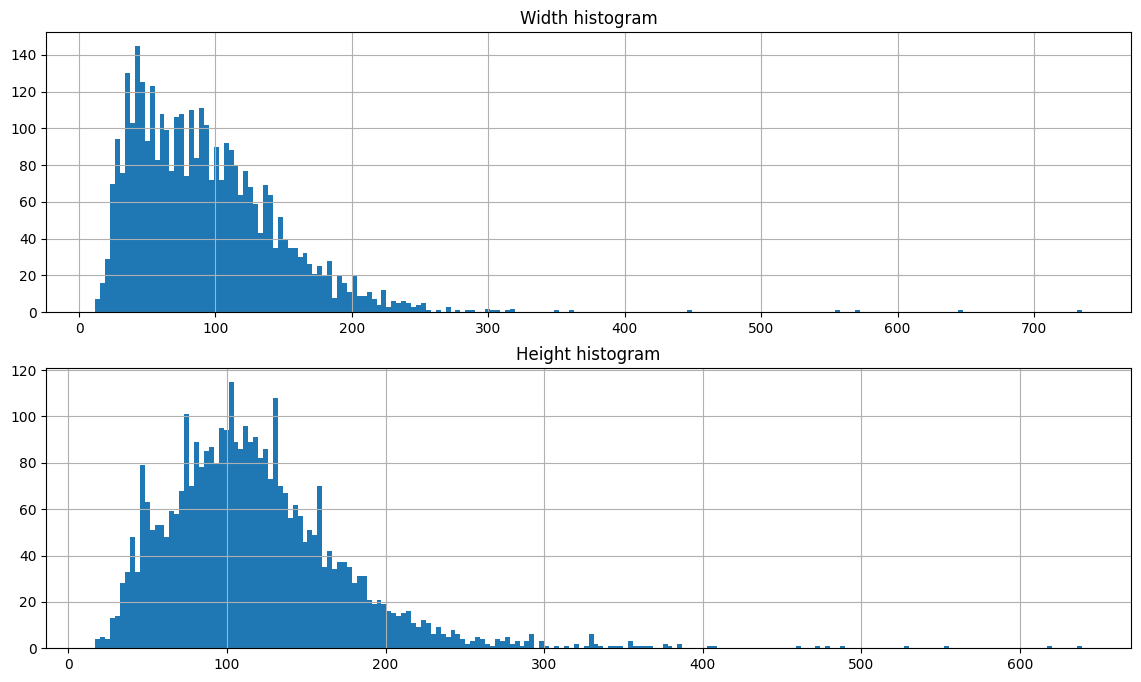

In [50]:
width_list = [0] * len(images)
height_list = [0] * len(images)

for i, image_path in enumerate(images):
    img = cv2.imread(image_path)
    width_list[i] = img.shape[1]
    height_list[i] = img.shape[0]

mean_width = sum(width_list) / len(width_list)
mean_height = sum(height_list) / len(height_list)

print(f"Mean image height: {mean_height}")
print(f"Mean image width: {mean_width}")

plt.figure(figsize=(14, 8))
plt.subplot(211)
plt.title("Width histogram")
plt.hist(width_list, bins=200)
plt.grid()

plt.subplot(212)
plt.title("Height histogram")
plt.hist(height_list, bins=200)
plt.grid()

plt.show()